In [ ]:
# ===== ENVIRONMENT SETUP =====
# This notebook requires the following Python packages:
# - astropy
# - plotly
#
# These can be installed using:
# pip install astropy plotly
#
# (Installation is not performed automatically to ensure compatibility across environments)

In [39]:
# ===== IMPORTS =====

# --- Standard library ---
import os
import glob
import re

# --- Data handling ---
import pandas as pd
import numpy as np

# --- Plotting ---
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go

# --- Astronomy / FITS handling ---
from astropy.io import fits

# --- Signal processing ---
from scipy.ndimage import median_filter
from scipy.signal import find_peaks

# --- Optimization ---
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

# --- Path handling (for GitHub portability) ---
from pathlib import Path

In [3]:
# --- Spectrum data access ---

# Base directory
BASE_PATH = Path().resolve().parent

# Data path
FAST_PATH = BASE_PATH / "data" / "FAST" / "2026-03-18"

# Locate files
hatp36_files = sorted(FAST_PATH.glob("*HATp36b*.fits"))
hiltner_files = sorted(FAST_PATH.glob("*Hiltner*.fits"))

# Check files exist
if not hatp36_files:
    raise FileNotFoundError("No HAT-P-36 files found")

if not hiltner_files:
    raise FileNotFoundError("No Hiltner files found")

# Select files
hatp36_file = hatp36_files[0]
hiltner_file = hiltner_files[0]

# Inspect HAT-P-36 FITS structure
with fits.open(hatp36_file) as hdul:
    print(f"\nHAT-P-36 file: {hatp36_file.name}")
    print(f"HDU count: {len(hdul)}")

    for i, hdu in enumerate(hdul):
        dtype = hdu.header.get('XTENSION', 'Primary')
        print(f"HDU {i}: {hdu.name}, {dtype}")

# Inspect Hiltner FITS structure
with fits.open(hiltner_file) as hdul:
    print(f"\nHiltner file: {hiltner_file.name}")
    print(f"HDU count: {len(hdul)}")

    for i, hdu in enumerate(hdul):
        dtype = hdu.header.get('XTENSION', 'Primary')
        print(f"HDU {i}: {hdu.name}, {dtype}")


HAT-P-36 file: 0059.HATp36b.fits
HDU count: 1
HDU 0: PRIMARY, Primary

Hiltner file: 0044.Hiltner600.fits
HDU count: 1
HDU 0: PRIMARY, Primary


In [4]:
# --- Inspect FITS headers ---

for label, file in [("HAT-P-36", hatp36_file), ("Hiltner", hiltner_file)]:

    with fits.open(file) as hdul:
        header = hdul[0].header

    print(f"\n--- {label} Primary Header ---")
    for key, value in header.items():
        print(f"{key}: {value}")


--- HAT-P-36 Primary Header ---
SIMPLE: True
BITPIX: 16
NAXIS: 2
NAXIS1: 2720
NAXIS2: 161
EXTEND: False
OBJECT: HATp36b
NAMPS: 1
DATE: 2026-03-19T08:04:53
DATE-OBS: 2026-03-19
RA: 12:33:03.89
DEC: +44:54:55.32
EPOCH: 2000
ROTANGLE: 095
FASTFOC: 1360
AIRMASS: 1.03
RRA: 12:33:03.89
RDEC: +44:54:55.32
REPOCH: 2000
TRA: 12:33:1.404
TDEC: 44:54:46.97
TEPOCH: 2000.00
ST:  12:38:57.07
HA:  00:05:53.69
DOME:  58.6
UT: 08:04:53
UTEND: 08:14:53
MJD: 61118.340197
GJDN: 2461118.840197
HJDN: 2461118.844248
SITENAME: flwo1
SITELONG: +110:52:39.0
SITELAT: +31:40:51.4
SITEELEV: 2320.0
DETECTOR: FAST3
CCDSERIA: STA520A SN4377
INSTRUME: FAST
OBSERVAT: flwo1
IRAFNAME: 0059.HATp36b.fits
DISKFILE: 59
DISKDIR: /data/fast/2026.0318
TELESCOP: TILLINGHAST
DISPAXIS: 1
EXPTIME: 600.0
DARKTIME: 600.0
IMAGETYP: OBJECT
BZERO: 32768.0
BSCALE: 1.0
CCDSUM: 1 2
BIN: 2
LTM1_1: 1.0
LTM2_2: 0.5
LTV1: 32.0
LTV2: 0.25
DATASEC: [33:2720,1:161]
CCDSEC: [33:2720,1:161]
TRIMSEC: [35:2715,1:161]
BIASSEC: [2:30,1:161]
GAIN: 0.8


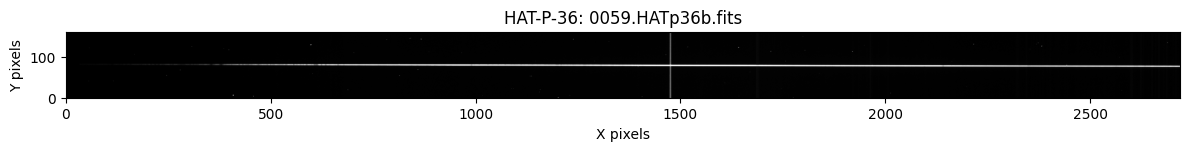

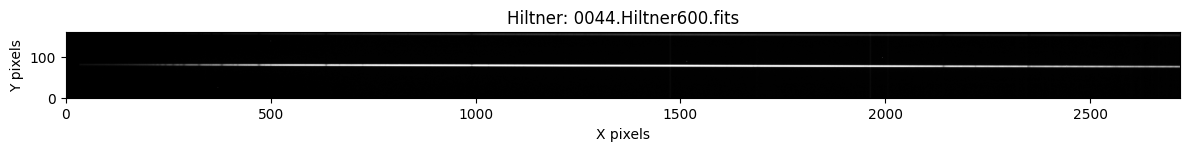

In [6]:
# --- Display raw science images ---

for label, file in [("HAT-P-36", hatp36_file), ("Hiltner", hiltner_file)]:

    with fits.open(file) as hdul:
        image_data = hdul[0].data

    fig, ax = plt.subplots(figsize=(12, 3))

    im = ax.imshow(
        image_data,
        origin='lower',
        cmap='gray',
        vmin=np.percentile(image_data, 1),
        vmax=np.percentile(image_data, 99)
    )

    ax.set_title(f"{label}: {file.name}")
    ax.set_xlabel("X pixels")
    ax.set_ylabel("Y pixels")

    plt.tight_layout()
    plt.show()

Found 41 bias files
Median bias created: (161, 2680)


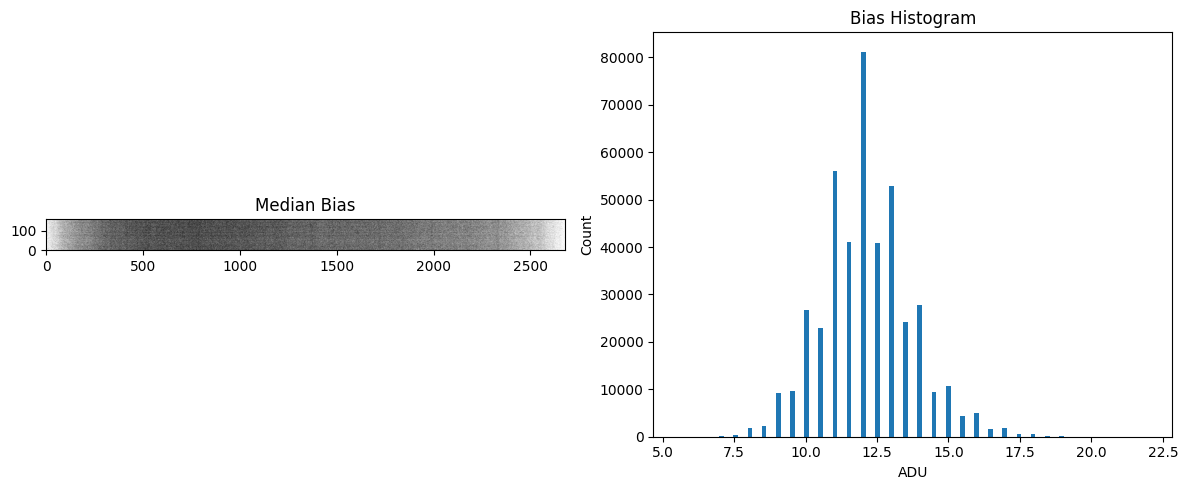

In [7]:
# --- Bias reduction ---

# Locate bias frames
bias_files = sorted(FAST_PATH.glob("*BIAS*.fits"))

print(f"Found {len(bias_files)} bias files")

if not bias_files:
    raise FileNotFoundError("No bias files found")

bias_stack = []

# Reduction parameters
oscan_start, oscan_end = 1, 29
trim_start, trim_end = 34, 2714
CCD_to_reduce = 0

for fn in bias_files:
    try:
        data = fits.getdata(fn, CCD_to_reduce)
    except IndexError:
        print(f"Skipping {fn.name} (missing HDU {CCD_to_reduce})")
        continue

    # Overscan subtraction
    overscan = data[:, oscan_start:oscan_end]
    bias_level = np.median(overscan, axis=1)
    data_corr = data - bias_level[:, None]

    # Trim
    data_trim = data_corr[:, trim_start:trim_end]

    bias_stack.append(data_trim)

# Median combine
bias_stack = np.array(bias_stack)
med_bias = np.median(bias_stack, axis=0)

print(f"Median bias created: {med_bias.shape}")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    med_bias,
    vmin=np.percentile(med_bias, 5),
    vmax=np.percentile(med_bias, 95),
    cmap="gray",
    origin="lower",
)
plt.title("Median Bias")

plt.subplot(1, 2, 2)
plt.hist(med_bias.flatten(), bins=100)
plt.title("Bias Histogram")
plt.xlabel("ADU")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Found 40 flat files
Median flat created: (161, 2680)


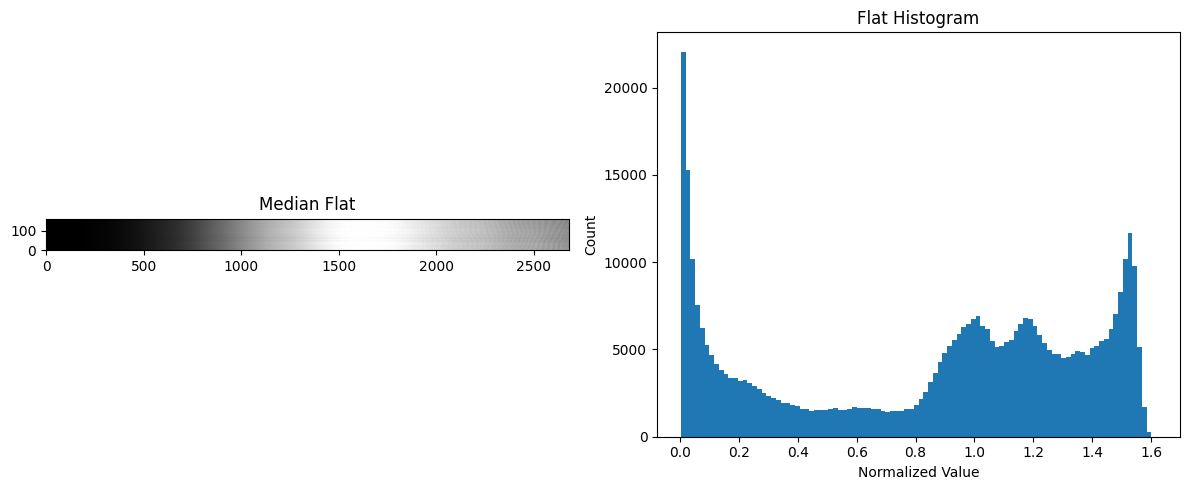

In [8]:
# --- Flat reduction ---

# Locate flat frames
flat_files = sorted(FAST_PATH.glob("*FLAT*.fits"))

print(f"Found {len(flat_files)} flat files")

if not flat_files:
    raise FileNotFoundError("No flat files found")

flat_stack = []

for fn in flat_files:
    try:
        data = fits.getdata(fn, CCD_to_reduce)
    except IndexError:
        print(f"Skipping {fn.name} (missing HDU {CCD_to_reduce})")
        continue

    # Overscan subtraction
    overscan = data[:, oscan_start:oscan_end]
    flat_level = np.median(overscan, axis=1)
    data_corr = data - flat_level[:, None]

    # Trim
    data_trim = data_corr[:, trim_start:trim_end]

    flat_stack.append(data_trim)

# Median combine
flat_stack = np.array(flat_stack)
med_flat = np.median(flat_stack, axis=0)

# Normalize
med_flat = med_flat / np.median(med_flat)

print(f"Median flat created: {med_flat.shape}")

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    med_flat,
    vmin=np.percentile(med_flat, 5),
    vmax=np.percentile(med_flat, 95),
    cmap="gray",
    origin="lower",
)
plt.title("Median Flat")

plt.subplot(1, 2, 2)
plt.hist(med_flat.flatten(), bins=100)
plt.title("Flat Histogram")
plt.xlabel("Normalized Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

HAT-P-36 reduced: 0059.HATp36b.fits
Shape: (161, 2680)


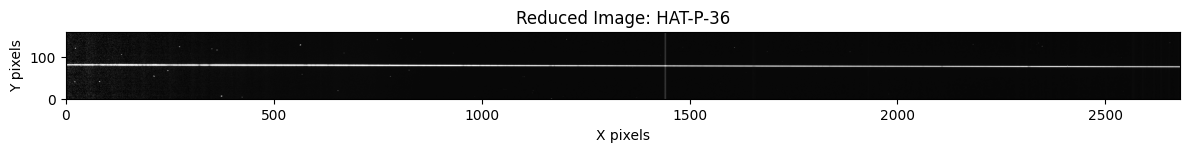

Hiltner reduced: 0044.Hiltner600.fits
Shape: (161, 2680)


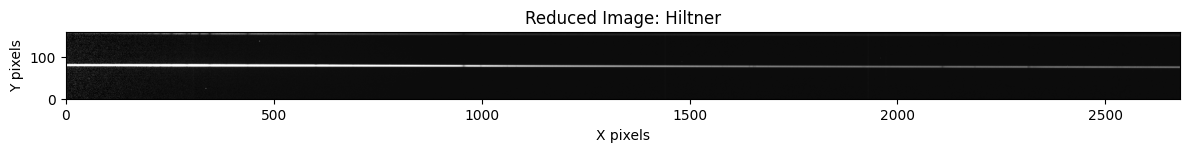

In [9]:
# --- Science reduction ---

reduced_images = {}

for label, file in [("HAT-P-36", hatp36_file), ("Hiltner", hiltner_file)]:

    # Load data
    science_data = fits.getdata(file, CCD_to_reduce)

    # Overscan subtraction
    overscan = science_data[:, oscan_start:oscan_end]
    bias_level = np.median(overscan, axis=1)
    science_corr = science_data - bias_level[:, None]

    # Trim
    science_trim = science_corr[:, trim_start:trim_end]

    # Bias subtraction
    science_biascorr = science_trim - med_bias

    # Flat fielding
    science_reduced = science_biascorr / med_flat

    reduced_images[label] = science_reduced

    print(f"{label} reduced: {file.name}")
    print(f"Shape: {science_reduced.shape}")

    # Visualization
    plt.figure(figsize=(12, 3))
    plt.imshow(
        science_reduced,
        vmin=np.percentile(science_reduced, 1),
        vmax=np.percentile(science_reduced, 99),
        cmap="gray",
        origin="lower"
    )
    plt.title(f"Reduced Image: {label}")
    plt.xlabel("X pixels")
    plt.ylabel("Y pixels")
    plt.tight_layout()
    plt.show()

HAT-P-36: trace peak at y = 80


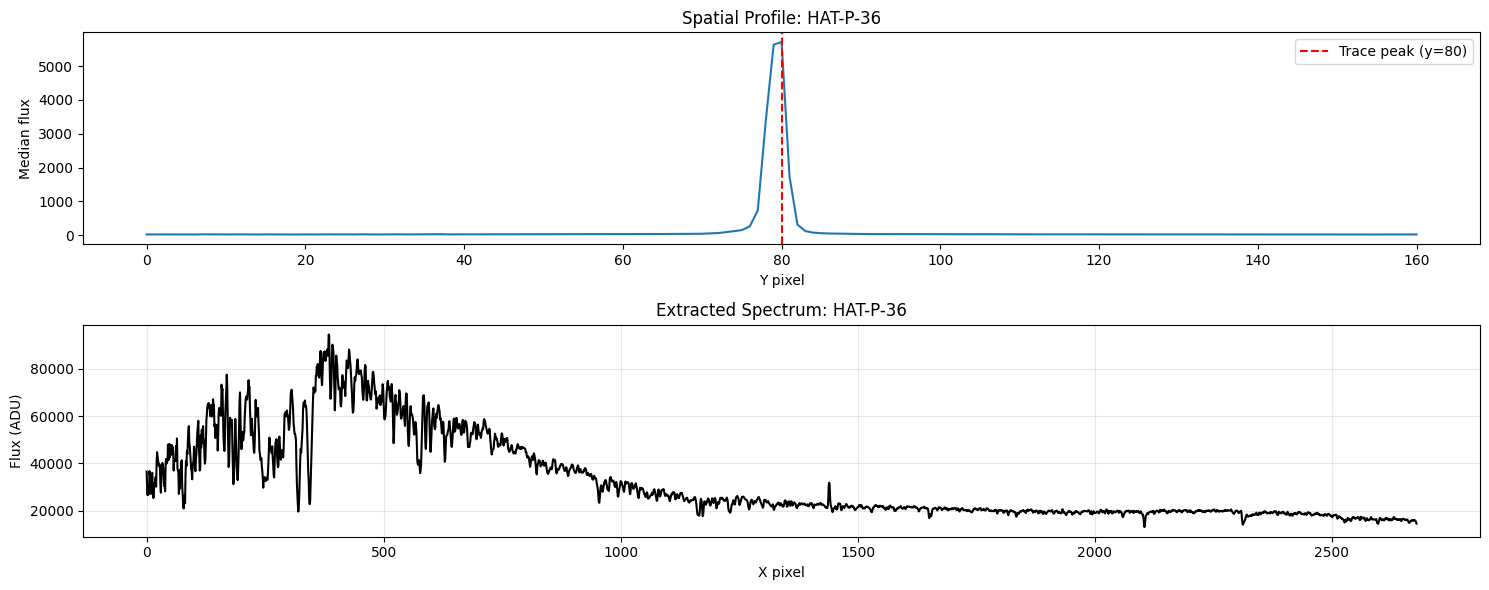

Hiltner: trace peak at y = 79


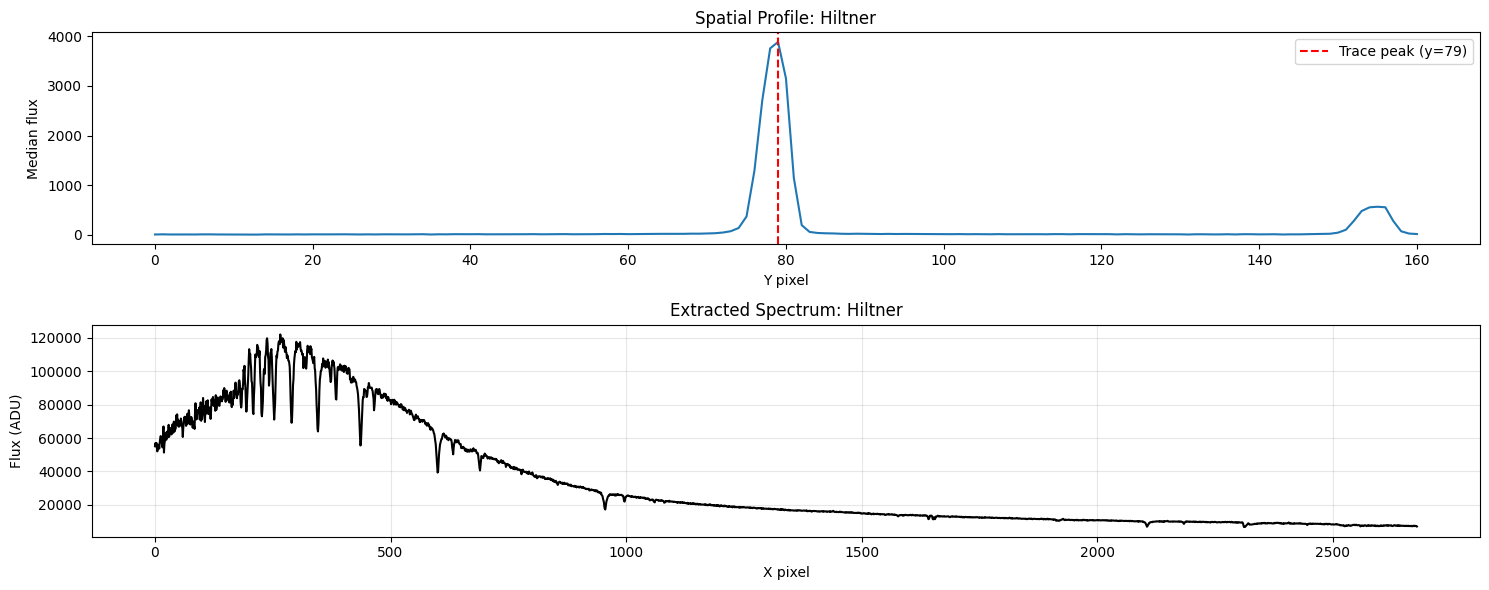

In [10]:
# --- 1D spectrum extraction ---

extracted_spectra = {}

for label, image in reduced_images.items():

    plt.figure(figsize=(15, 6))

    # Find spatial profile
    spatial_profile = np.nanmedian(image, axis=1)
    y_peak = np.argmax(spatial_profile)

    # Plot spatial profile
    plt.subplot(2, 1, 1)
    plt.plot(spatial_profile)
    plt.axvline(y_peak, color='red', linestyle='--',
                label=f"Trace peak (y={y_peak})")
    plt.title(f"Spatial Profile: {label}")
    plt.xlabel("Y pixel")
    plt.ylabel("Median flux")
    plt.legend()

    print(f"{label}: trace peak at y = {y_peak}")

    # Extract 1D spectrum
    aperture_half_width = 3

    y_min = max(0, y_peak - aperture_half_width)
    y_max = min(image.shape[0], y_peak + aperture_half_width)

    spectrum_1d = np.nansum(image[y_min:y_max, :], axis=0)

    extracted_spectra[label] = spectrum_1d

    # Plot extracted spectrum
    plt.subplot(2, 1, 2)
    plt.plot(spectrum_1d, color='black')
    plt.title(f"Extracted Spectrum: {label}")
    plt.xlabel("X pixel")
    plt.ylabel("Flux (ADU)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

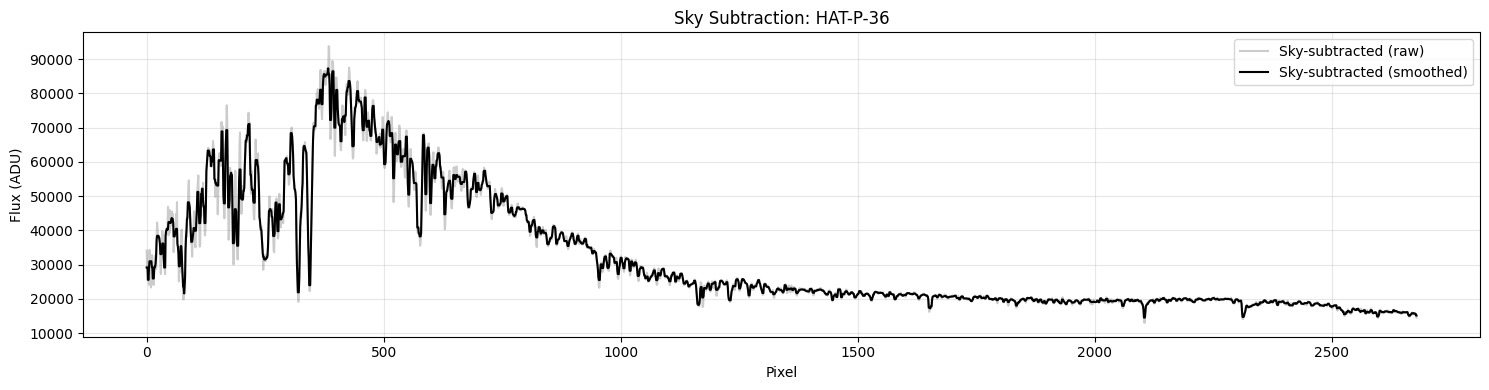

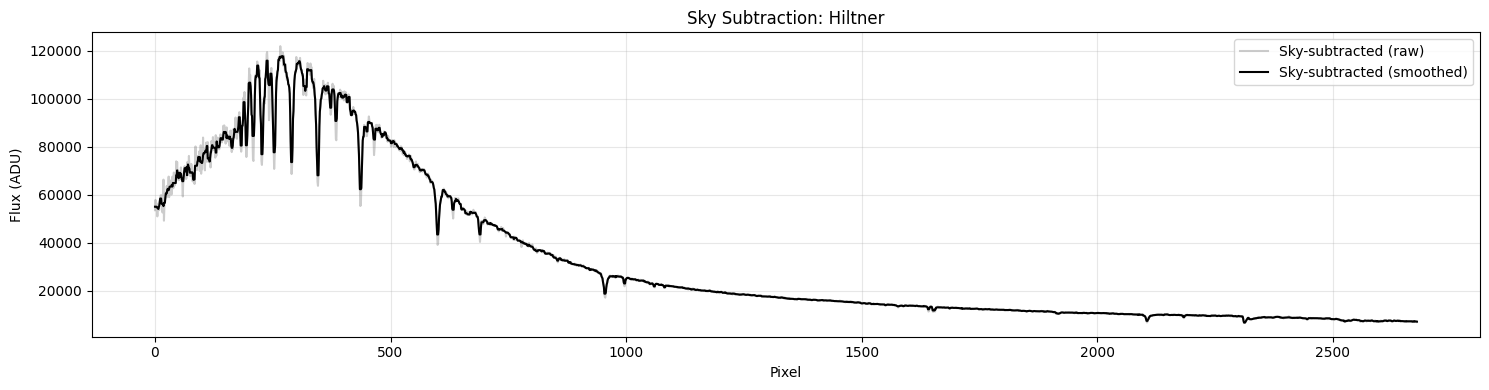

In [11]:
# --- Sky subtraction ---

sky_subtracted_spectra = {}

for label in reduced_images:

    image = reduced_images[label]
    spectrum_1d = extracted_spectra[label]

    # Define sky regions
    sky_region_low = image[20:50, :]
    sky_region_high = image[110:140, :]
    sky_regions = np.concatenate([sky_region_low, sky_region_high], axis=0)

    # Master sky spectrum
    sky_spectrum_1d = np.nanmedian(sky_regions, axis=0)

    # Scale to extraction aperture
    aperture_factor = 2 * aperture_half_width
    sky_scaled = sky_spectrum_1d * aperture_factor

    # Subtract sky
    spectrum_sky_sub = spectrum_1d - sky_scaled

    # Smooth
    spectrum_smoothed = median_filter(spectrum_sky_sub, size=5)

    sky_subtracted_spectra[label] = spectrum_smoothed

    # Visualization
    plt.figure(figsize=(15, 4))
    plt.plot(spectrum_sky_sub, color='gray', alpha=0.4,
             label='Sky-subtracted (raw)')
    plt.plot(spectrum_smoothed, color='black',
             label='Sky-subtracted (smoothed)')
    plt.title(f"Sky Subtraction: {label}")
    plt.xlabel("Pixel")
    plt.ylabel("Flux (ADU)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Found 1 arc files
Using arc file: 0060.COMP.fits


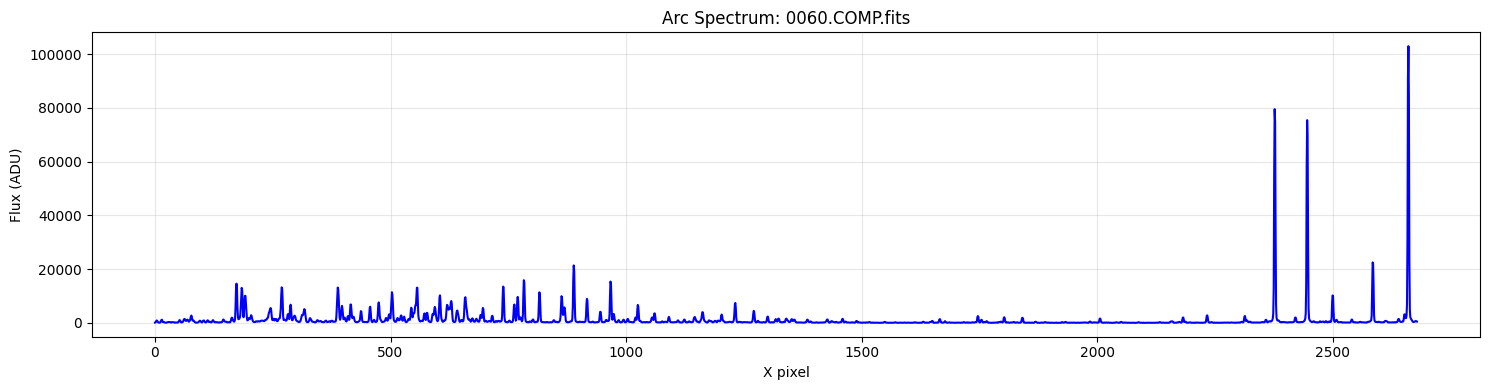

In [12]:
# --- Arc lamp reduction ---

# Locate arc frames
arc_files = sorted(FAST_PATH.glob("*COMP*.fits"))

print(f"Found {len(arc_files)} arc files")

if not arc_files:
    raise FileNotFoundError("No arc files found")

# Use first arc frame
arc_file = arc_files[0]
print(f"Using arc file: {arc_file.name}")

# Load data
arc_data = fits.getdata(arc_file, CCD_to_reduce)

# Overscan subtraction
arc_overscan = arc_data[:, oscan_start:oscan_end]
arc_bias_level = np.median(arc_overscan, axis=1)
arc_corr = arc_data - arc_bias_level[:, None]

# Trim and bias subtract
arc_trim = arc_corr[:, trim_start:trim_end]
arc_reduced = arc_trim - med_bias

# Extract 1D arc spectrum using same aperture as science
arc_spectrum_1d = np.nansum(arc_reduced[y_min:y_max, :], axis=0)

# Visualization
plt.figure(figsize=(15, 4))
plt.plot(arc_spectrum_1d, color="blue")
plt.title(f"Arc Spectrum: {arc_file.name}")
plt.xlabel("X pixel")
plt.ylabel("Flux (ADU)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Detected 47 arc lines


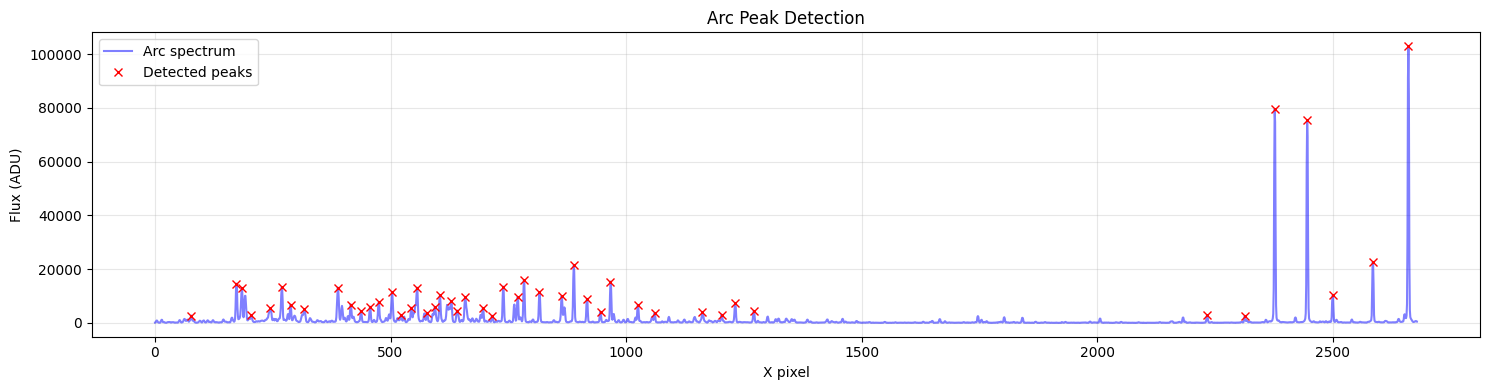

In [13]:
# --- Arc peak detection ---

peaks, properties = find_peaks(
    arc_spectrum_1d,
    height=np.percentile(arc_spectrum_1d, 90),
    distance=10
)

detected_pixels = peaks
print(f"Detected {len(detected_pixels)} arc lines")

# Visualization
plt.figure(figsize=(15, 4))
plt.plot(arc_spectrum_1d, color="blue", alpha=0.5, label="Arc spectrum")

plt.plot(
    detected_pixels,
    arc_spectrum_1d[detected_pixels],
    "x",
    color="red",
    label="Detected peaks"
)

plt.title("Arc Peak Detection")
plt.xlabel("X pixel")
plt.ylabel("Flux (ADU)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

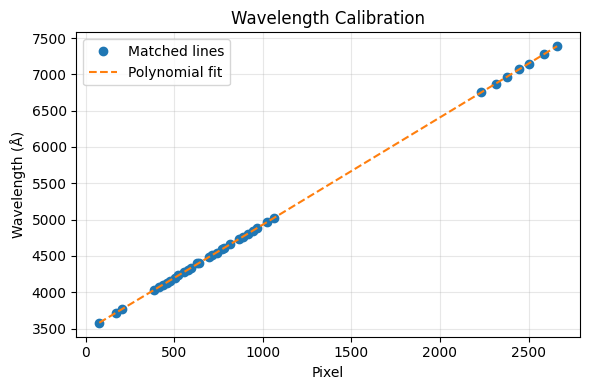

In [15]:
# --- Wavelength calibration (argon arc) ---

# Argon lamp reference table (provided)
Ar_lamp = """
	         69.83 3575.40181  3577.6364   4.0 1 1 ArII
	        173.81 3724.56556  3719.2638   4.0 1 1 ArII
	        200.30 3762.70113  3767.1883   4.0 1 1 ArII
	        389.14 4036.03156  4034.9488   4.0 1 1 ArII
	        397.75 4048.55337   4045.561   4.0 1 1 ArII
	        416.37 4075.63949  4073.1541   4.0 1 1 ArI
	        438.19 4107.41827    4105.07   4.0 1 1 ArII
	        457.35 4135.33392  4132.8886   4.0 1 1 ArII
	        475.71 4162.10809   4159.762   4.0 1 1 ArII
	        497.89 4194.48163   4201.858   4.0 1 1 ArI
	        523.36 4231.67628  4238.4126   4.0 1 1 ArI
	        557.22 4281.17982  4278.7316   4.0 1 1 ArII
	        572.78 4303.95145  4301.8591   4.0 1 1 ArI
	        590.92 4330.50502   4334.779   4.0 1 1 ArII
	        642.35 4405.88237  4402.2222   4.0 1 1 ArII
	        692.30  4479.2032  4483.0679   4.0 1 1 ArI
	        710.87 4506.48197   4511.998   4.0 1 1 ArII
	        740.21 4549.61034  4546.3258   4.0 1 1 ArII
	        763.62 4584.04803  4580.6326   4.0 1 1 ArII
	        770.81 4594.62313  4591.1837   4.0 1 1 ArII
	        776.48 4602.96328  4610.8582   4.0 1 1 ArI
	        817.14 4662.82399   4659.205   4.0 1 1 ArII
	        864.14 4732.08769  4737.2302   4.0 1 1 ArII
	        889.98 4770.18611  4766.1968   4.0 1 1 ArII
	        917.99 4811.49062  4807.3635   4.0 1 1 ArI
	        946.37 4853.37534  4849.1639   4.0 1 1 ArII
	        968.19 4885.57568  4881.2263   4.0 1 1 ArII
	       1020.98 4963.51916  4966.4649   4.0 1 1 ArII
	       1056.26 5015.62824  5018.5619   4.0 1 1 ArII
	       1084.34 5057.12633  5063.4483   4.0 1 1 ArII
	       1747.80 6036.35344   6033.797   4.0 1 1 ArII
	       1842.34 6175.70772  6173.9855   4.0 1 1 ArII
	       2183.31 6678.67084   6679.126   4.0 1 1 ArII
	       2234.43 6754.18301   6754.698   4.0 1 1 ArII
	       2314.47 6872.49738   6873.185   4.0 1 1 ArII
	       2378.10  6966.6166   6967.352   4.0 1 1 ArI
	       2421.98 7031.56808    7032.19   4.0 1 1 ArII
	       2447.01 7068.64731   7069.167   4.0 1 1 ArII
	       2501.04 7148.70742   7148.012   4.0 1 1 ArII
	       2586.37 7275.29815    7274.94   4.0 1 1 ArI
	       2661.77 7387.30618   7386.014   4.0 1 1 ArI
"""

# Parse reference lines
initial_pixels = []
initial_wavelengths = []
ref_lambdas = []

for line in Ar_lamp.strip().split("\n"):
    parts = line.split()
    if len(parts) >= 3:
        initial_pixels.append(float(parts[0]))
        initial_wavelengths.append(float(parts[1]))
        ref_lambdas.append(float(parts[2]))

initial_pixels = np.array(initial_pixels)
initial_wavelengths = np.array(initial_wavelengths)
ref_lambdas = np.sort(np.unique(ref_lambdas))

# Initial wavelength solution
initial_poly = np.poly1d(np.polyfit(initial_pixels, initial_wavelengths, 2))
detected_waves = initial_poly(detected_pixels)

# Match detected peaks to reference lines
matched_pixels = []
matched_wavelengths = []

tolerance = 15.0

for i, pixel in enumerate(detected_pixels):
    diffs = np.abs(ref_lambdas - detected_waves[i])
    idx = np.argmin(diffs)

    if diffs[idx] < tolerance:
        matched_pixels.append(pixel)
        matched_wavelengths.append(ref_lambdas[idx])

matched_pixels = np.array(matched_pixels)
matched_wavelengths = np.array(matched_wavelengths)

# Refined wavelength solution
final_poly = np.poly1d(np.polyfit(matched_pixels, matched_wavelengths, 2))

# Apply to full spectrum
wavelengths = final_poly(np.arange(len(spectrum_1d)))

# Diagnostic plot
plt.figure(figsize=(6, 4))
plt.plot(matched_pixels, matched_wavelengths, "o", label="Matched lines")
plt.plot(
    matched_pixels,
    final_poly(matched_pixels),
    "--",
    label="Polynomial fit"
)

plt.xlabel("Pixel")
plt.ylabel("Wavelength (Å)")
plt.title("Wavelength Calibration")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

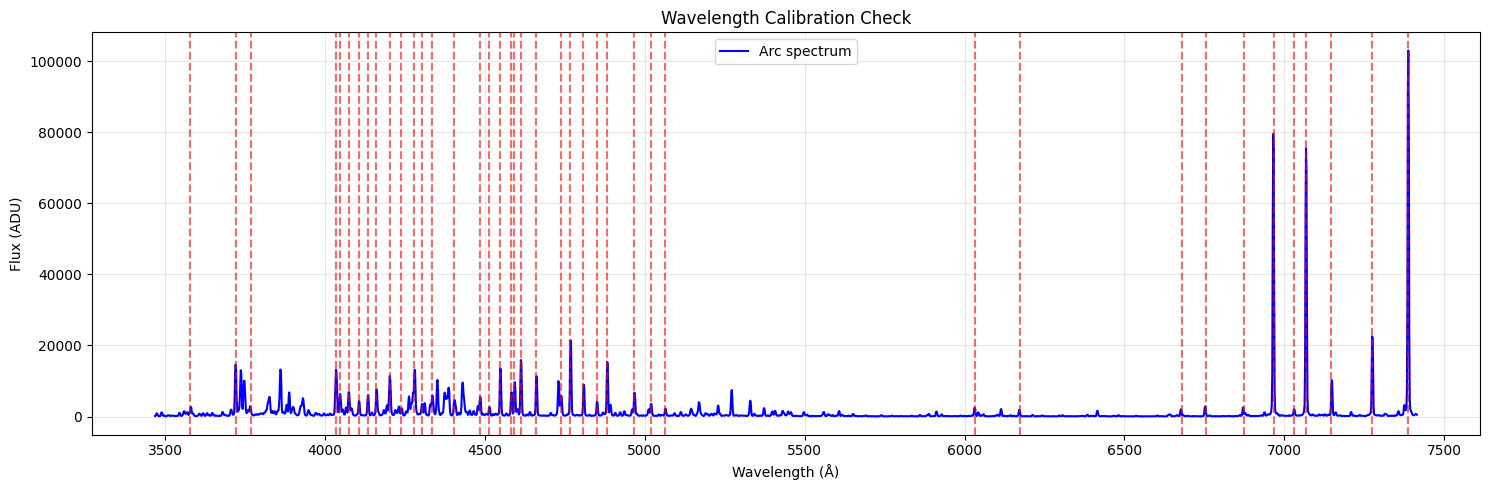

In [16]:
# --- Wavelength calibration check ---

plt.figure(figsize=(15, 5))

# Calibrated arc spectrum
plt.plot(wavelengths, arc_spectrum_1d, color="blue", label="Arc spectrum")

# Reference lines
for wave in ref_lambdas:
    plt.axvline(wave, color="red", linestyle="--", alpha=0.6)

# Label a strong reference line
if 7514.7 in ref_lambdas:
    plt.text(
        7514.7,
        np.max(arc_spectrum_1d),
        "7514.7 Å",
        rotation=90,
        verticalalignment="top",
        color="red"
    )

plt.title("Wavelength Calibration Check")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (ADU)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

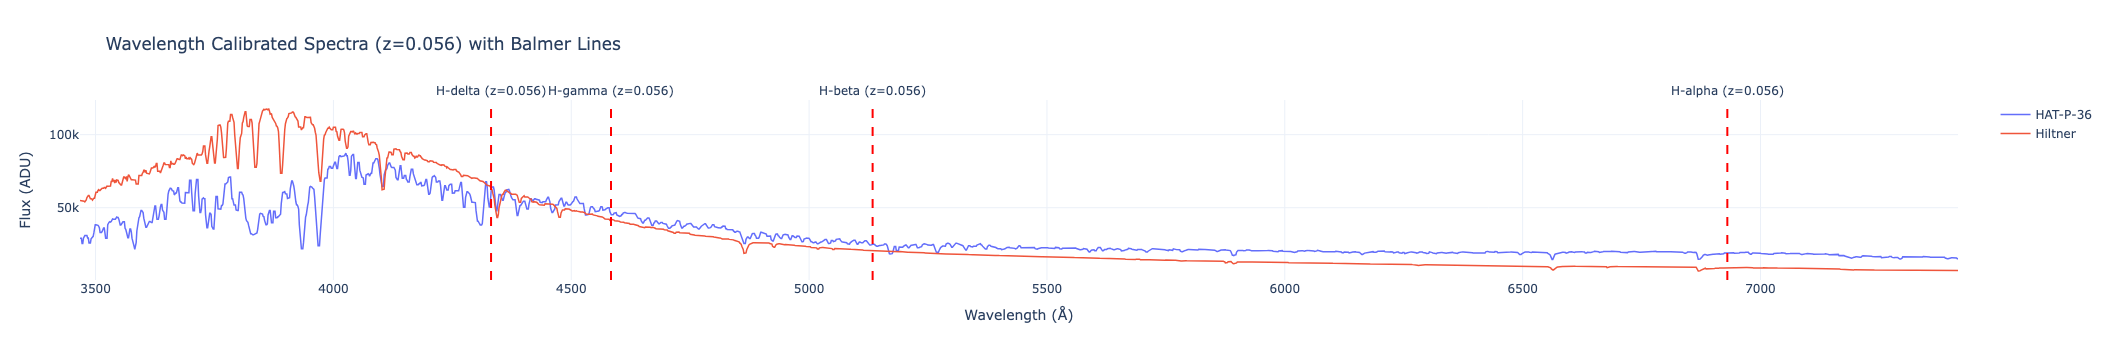

In [20]:
# --- Wavelength calibrated spectra ---

# Redshift
z = 0.056

# Balmer rest wavelengths (Å)
balmer_rest = {
    'H-alpha': 6562.8,
    'H-beta': 4861.3,
    'H-gamma': 4340.5,
    'H-delta': 4101.7
}

# Interactive spectrum
fig_cal = go.Figure()

# Plot calibrated spectra
for label in sky_subtracted_spectra:
    fig_cal.add_trace(go.Scatter(
        x=wavelengths,
        y=sky_subtracted_spectra[label],
        mode='lines',
        line=dict(width=1.5),
        name=label
    ))

# Overlay redshifted Balmer lines
for line_name, rest_wave in balmer_rest.items():
    obs_wave = rest_wave * (1 + z)

    fig_cal.add_vline(
        x=obs_wave,
        line_dash="dash",
        line_color="red",
        annotation_text=f"{line_name} (z={z})",
        annotation_position="top"
    )

# Layout
fig_cal.update_layout(
    title=f"Wavelength Calibrated Spectra (z={z}) with Balmer Lines",
    xaxis_title="Wavelength (Å)",
    yaxis_title="Flux (ADU)",
    template="plotly_white",
    hovermode="x",
    xaxis=dict(range=[wavelengths[0], wavelengths[-1]])
)

fig_cal.show()

In [22]:
# ----- Load ESO standard star (Hiltner) -----

# File contains calibrated reference spectrum
# Column 0: wavelength (Å)
# Column 1: flux (physical units)

eso_file = FAST_PATH / "fhilt600.dat"

# Load data
eso_data = np.loadtxt(eso_file)

# Extract wavelength and flux
eso_wavelengths = eso_data[:, 0]
eso_flux = eso_data[:, 1]

# Sanity check
print(f"Loaded ESO file: {eso_file.name}")
print(f"Data shape: {eso_data.shape}")
print(f"Wavelength range: {eso_wavelengths.min()} – {eso_wavelengths.max()} Å")

Loaded ESO file: fhilt600.dat
Data shape: (137, 4)
Wavelength range: 3300.0 – 10100.0 Å


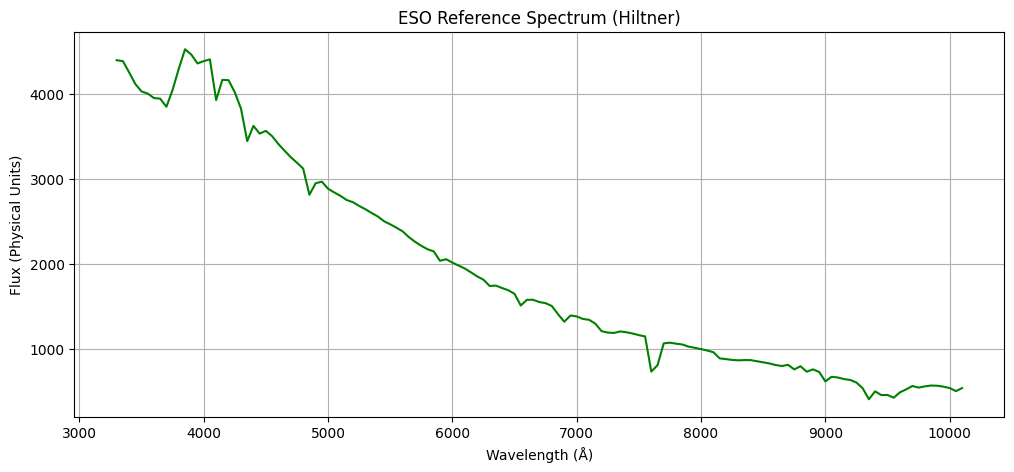

In [23]:
# ----- Visualize ESO standard star -----

plt.figure(figsize=(12, 5))

plt.plot(eso_wavelengths, eso_flux, color='green')

plt.title("ESO Reference Spectrum (Hiltner)")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (Physical Units)")

plt.grid(True)
plt.show()

In [24]:
# ----- Interpolate ESO spectrum onto our wavelength grid -----

# Create interpolation function
eso_interp_func = interp1d(
    eso_wavelengths,
    eso_flux,
    bounds_error=False,
    fill_value="extrapolate"
)

# Evaluate ESO flux on our wavelength grid
eso_flux_interp = eso_interp_func(wavelengths)

# Sanity check
print(f"Interpolated ESO flux shape: {eso_flux_interp.shape}")

Interpolated ESO flux shape: (2680,)


In [25]:
# ----- Compute instrument response function -----

response_functions = {}

for label in sky_subtracted_spectra:

    spectrum = sky_subtracted_spectra[label]

    # Avoid division issues
    valid = spectrum > 0

    response = np.zeros_like(spectrum)
    response[valid] = eso_flux_interp[valid] / spectrum[valid]

    response_functions[label] = response

    # Sanity check
    print(f"{label} response shape: {response.shape}")

HAT-P-36 response shape: (2680,)
Hiltner response shape: (2680,)


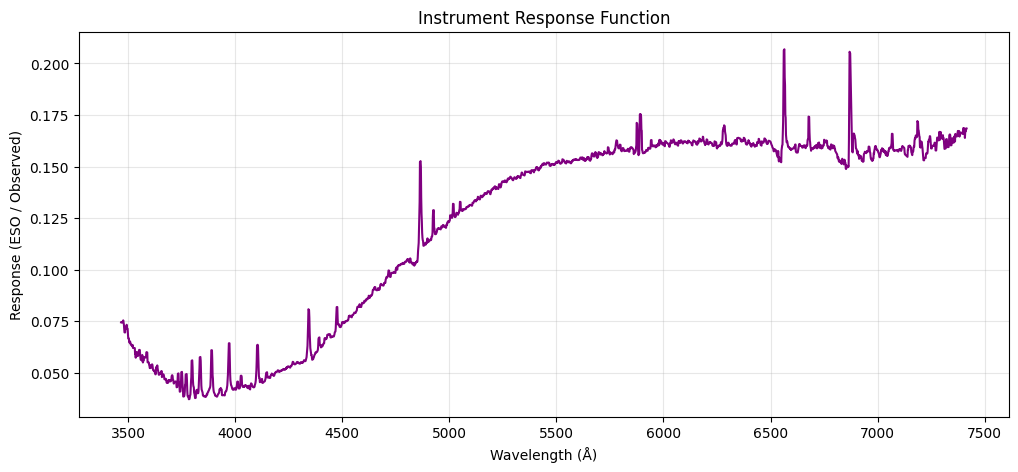

In [26]:
# ----- Visualize response function -----

plt.figure(figsize=(12, 5))

response = response_functions["Hiltner"]

plt.plot(wavelengths, response, color='purple')

plt.title("Instrument Response Function")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Response (ESO / Observed)")
plt.grid(True, alpha=0.3)

plt.show()

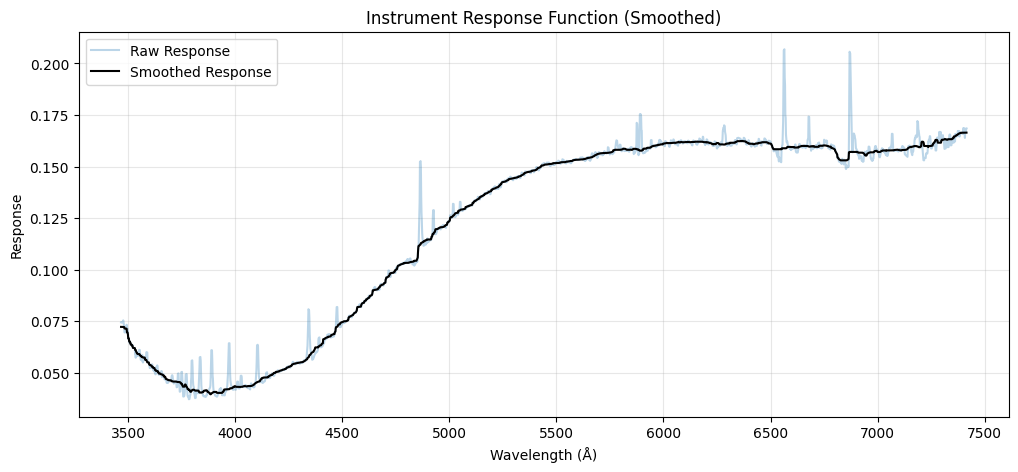

In [27]:
# ----- Smooth response function -----

response = response_functions["Hiltner"]
response_smooth = median_filter(response, size=51)

plt.figure(figsize=(12, 5))

plt.plot(wavelengths, response, alpha=0.3, label='Raw Response')
plt.plot(wavelengths, response_smooth, color='black', label='Smoothed Response')

plt.title("Instrument Response Function (Smoothed)")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Response")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

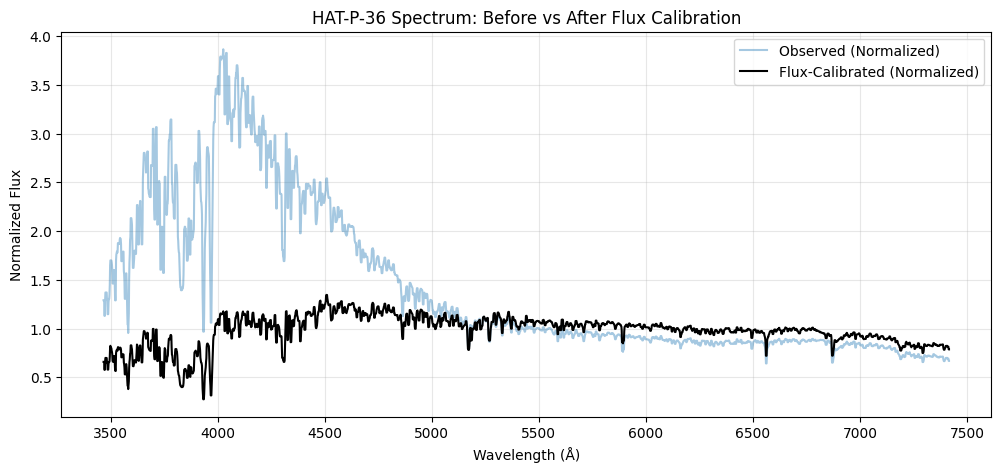

In [28]:
# ----- Apply instrument response to HAT-P-36 -----

hatp36_spectrum = sky_subtracted_spectra["HAT-P-36"]
hatp36_calibrated = hatp36_spectrum * response_smooth

# Normalize for comparison
hat_norm_factor = np.median(hatp36_calibrated)

hatp36_raw_norm = hatp36_spectrum / np.median(hatp36_spectrum)
hatp36_calibrated_norm = hatp36_calibrated / hat_norm_factor

# ----- Plot result -----

plt.figure(figsize=(12, 5))

plt.plot(wavelengths, hatp36_raw_norm, alpha=0.4, label='Observed (Normalized)')
plt.plot(wavelengths, hatp36_calibrated_norm, color='black', label='Flux-Calibrated (Normalized)')

plt.title("HAT-P-36 Spectrum: Before vs After Flux Calibration")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [29]:
# ----- Fit blackbody to HAT-P-36 -----

# Physical constants
h = 6.626e-34   # Planck constant (J·s)
c = 3.0e8       # speed of light (m/s)
k = 1.381e-23   # Boltzmann constant (J/K)

# Convert Angstroms to meters
wavelength_m = wavelengths * 1e-10

# Planck function
def planck(wavelength, T, scale):
    return scale * (2*h*c**2 / wavelength**5) / (np.exp(h*c / (wavelength*k*T)) - 1)

# Initial guess
initial_guess = [6000, 1e-16]

# Fit model
popt, _ = curve_fit(planck, wavelength_m, hatp36_calibrated, p0=initial_guess)

T_fit, scale_fit = popt

print(f"Estimated Temperature: {T_fit:.0f} K")

Estimated Temperature: 5583 K


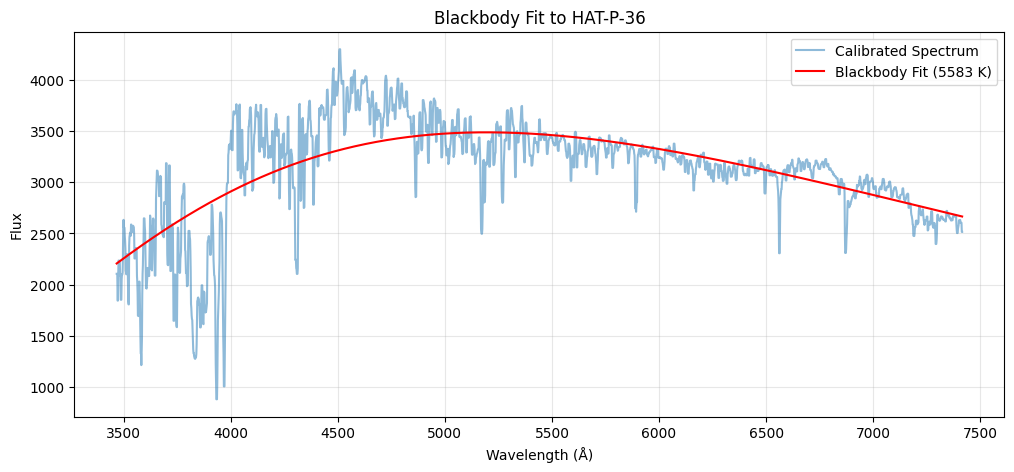

In [30]:
# ----- Plot blackbody fit -----

bb_fit = planck(wavelength_m, T_fit, scale_fit)

plt.figure(figsize=(12, 5))

plt.plot(wavelengths, hatp36_calibrated, alpha=0.5, label='Calibrated Spectrum')
plt.plot(wavelengths, bb_fit, color='red', label=f'Blackbody Fit ({T_fit:.0f} K)')

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Blackbody Fit to HAT-P-36")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()